<!-- @@COLAB@@ -->
<a href="https://colab.research.google.com/github/laris-co/ajfon-oracle/blob/main/book/notebooks/ch06_ann_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **เปิดใน Google Colab** — คลิกป้ายด้านบน รันได้ทันทีบนคลาวด์ฟรี ไม่ต้องติดตั้งอะไรในเครื่อง (เซลล์แรกจะ `pip install` ให้เอง)


# 📗 บทที่ 6 — ANN: ค้นแสนโน้ตในมิลลิวินาที (วัดเวลาจริง)

**คู่กับ:** หนังสือบทที่ 6

บทที่ 4 บอกว่า vector DB = "หา cosine สูงสุดแบบเร็วมาก" — บทนี้**วัดจริง**ว่าเร็วแค่ไหน
และทำไมไม่ต้องเทียบทุกตัว (Approximate Nearest Neighbor)


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %pip -q install chromadb matplotlib
import numpy as np, time, chromadb, matplotlib
import matplotlib.pyplot as plt
import platform
from matplotlib import font_manager as _fm
if platform.system() == 'Darwin':
    matplotlib.rcParams['font.family'] = 'Thonburi'
else:
    _av={f.name for f in _fm.fontManager.ttflist}
    if 'Loma' not in _av:
        import subprocess
        subprocess.run(['apt-get','-qq','install','-y','fonts-thai-tlwg'], capture_output=True)
        for _p in _fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/tlwg']):
            _fm.fontManager.addfont(_p)
    matplotlib.rcParams['font.family'] = 'Loma'
matplotlib.rcParams['axes.unicode_minus'] = False
print('พร้อม ✓')


พร้อม ✓


## 1) สร้าง "vault จำลอง" — เวกเตอร์สุ่ม N ตัว (แทน embedding ของโน้ต N ชิ้น)

ใช้เวกเตอร์สุ่ม normalize แล้ว — คณิตเหมือน embedding จริงทุกประการ (Ch4)


In [2]:
def make_vault(n, dim=1024, seed=42):
    rng = np.random.default_rng(seed)
    V = rng.standard_normal((n, dim)).astype(np.float32)
    return V / np.linalg.norm(V, axis=1, keepdims=True)

vault = make_vault(100_000)
query = make_vault(1, seed=7)[0]
print(f'vault จำลอง: {vault.shape[0]:,} โน้ต × {vault.shape[1]} มิติ ({vault.nbytes/1e6:.0f} MB)')


vault จำลอง: 100,000 โน้ต × 1024 มิติ (410 MB)


## 2) วิธีตรงไปตรงมา: brute force — เทียบ**ทุกตัว**


In [3]:
t0 = time.perf_counter()
scores = vault @ query          # cosine ทุกตัว (normalize แล้ว → dot = cosine)
top5 = np.argsort(-scores)[:5]
bf_ms = (time.perf_counter() - t0) * 1000
print(f'brute force 100,000 โน้ต: {bf_ms:.1f} ms   → top-5: {top5.tolist()}')


brute force 100,000 โน้ต: 11.2 ms   → top-5: [31702, 21446, 68602, 55488, 57813]


## 3) วัดการโต: เวลา brute force เพิ่มตามจำนวนโน้ตยังไง


    1,000 โน้ต →    0.04 ms
   10,000 โน้ต →    0.61 ms


   50,000 โน้ต →    4.24 ms


  100,000 โน้ต →    9.18 ms


  200,000 โน้ต →   19.42 ms


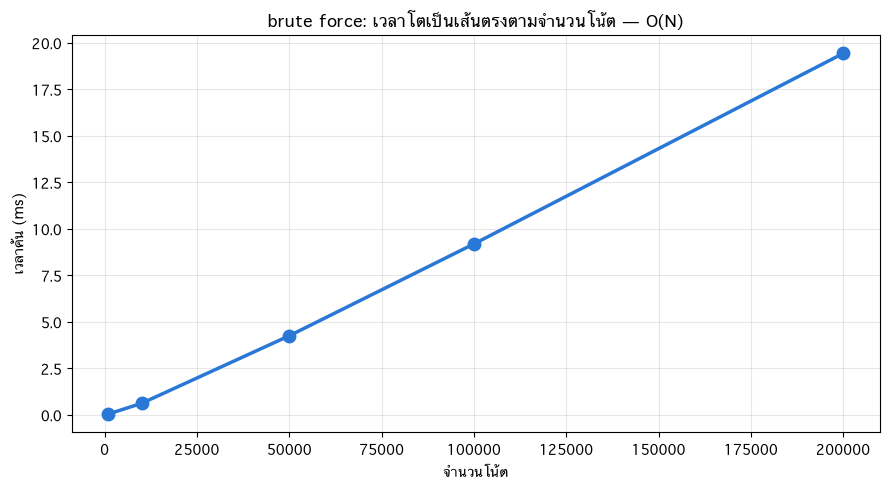

In [4]:
sizes = [1_000, 10_000, 50_000, 100_000, 200_000]
times = []
for n in sizes:
    V = make_vault(n)
    t0 = time.perf_counter()
    for _ in range(5):
        _ = np.argsort(-(V @ query))[:5]
    times.append((time.perf_counter() - t0) / 5 * 1000)
    print(f'{n:>9,} โน้ต → {times[-1]:7.2f} ms')

plt.figure(figsize=(9, 5))
plt.plot(sizes, times, 'o-', color='#2a78d6', lw=2.5, markersize=9)
plt.xlabel('จำนวนโน้ต'); plt.ylabel('เวลาค้น (ms)')
plt.title('brute force: เวลาโตเป็นเส้นตรงตามจำนวนโน้ต — O(N)')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()


## 4) ระดับล้านโน้ต brute force เริ่มหนัก → **ANN**: ฉลาดกว่า ไม่เทียบทุกตัว

ChromaDB ใช้ **HNSW** (กราฟทางลัด): กระโดดจากจุดหนึ่งไปจุดใกล้กว่าเรื่อยๆ
เหมือนถามทาง — ไม่ต้องเคาะประตูทุกบ้านในเมือง

💡 `search_ef` คือ "ปุ่มหมุน" recall↔ความเร็ว: สูง=ค้นละเอียด (ช้าขึ้น แม่นขึ้น) · ต่ำ=เร็วแต่พลาดได้
เวกเตอร์สุ่มคือโจทย์ที่ยากที่สุดของ ANN (ไม่มีโครงสร้างกลุ่มเลย) — เราตั้ง ef=200 เพื่อ recall ดี


In [5]:
import shutil
shutil.rmtree('./chroma_bench', ignore_errors=True)   # เริ่มสะอาดทุกครั้ง (reproducible)
client = chromadb.PersistentClient(path='./chroma_bench')
col = client.create_collection('bench', metadata={
    'hnsw:space': 'cosine',
    'hnsw:search_ef': 200,        # ปุ่มหมุนตอนค้น: สูง=แม่น/ช้าขึ้น
    'hnsw:construction_ef': 200,  # ปุ่มหมุนตอนสร้างกราฟ: สูง=กราฟดี
    'hnsw:M': 32,                 # จำนวนเพื่อนต่อ node ในกราฟ
})

N = 20_000
V = make_vault(N)
t0 = time.perf_counter()
B = 5000
for i in range(0, N, B):
    col.add(ids=[str(j) for j in range(i, min(i+B, N))],
            embeddings=V[i:i+B].tolist())
print(f'สร้าง HNSW index {N:,} เวกเตอร์: {time.perf_counter()-t0:.1f}s (จ่ายครั้งเดียวตอน ingest)')


สร้าง HNSW index 20,000 เวกเตอร์: 20.5s (จ่ายครั้งเดียวตอน ingest)


In [6]:
# วัดเวลา query: HNSW vs brute force บนข้อมูลเดียวกัน
t0 = time.perf_counter()
for _ in range(20):
    r = col.query(query_embeddings=[query.tolist()], n_results=5)
hnsw_ms = (time.perf_counter() - t0) / 20 * 1000

t0 = time.perf_counter()
for _ in range(20):
    bf_top = np.argsort(-(V @ query))[:5]
bf20_ms = (time.perf_counter() - t0) / 20 * 1000

print(f'HNSW (ChromaDB): {hnsw_ms:6.2f} ms/query')
print(f'brute force:     {bf20_ms:6.2f} ms/query')
print()
hnsw_top = [int(x) for x in r['ids'][0]]
overlap = len(set(hnsw_top) & set(bf_top.tolist()))
print(f'top-5 ตรงกัน {overlap}/5 → ANN = "approximate" แลกความเป๊ะนิดเดียวกับความเร็ว')


HNSW (ChromaDB):   8.05 ms/query
brute force:       1.62 ms/query

top-5 ตรงกัน 5/5 → ANN = "approximate" แลกความเป๊ะนิดเดียวกับความเร็ว


## ✅ วัดผลตัวเอง #6


In [7]:
assert bf_ms < 1000, 'brute force แสนโน้ตควรเสร็จใน 1 วินาที (numpy เร็วกว่าที่คิด!)'
assert overlap >= 4, 'HNSW (ef=200) ควรเจอ top-5 ตรงกับ brute force อย่างน้อย 4/5'
ratio = times[-1] / times[0]
assert ratio > 50, 'เวลา brute force ควรโตตามขนาดชัดเจน (O(N))'
print('✅ ผ่าน! เห็นด้วยตาแล้ว: O(N) ของ brute force · recall ของ ANN · trade-off จริง')
print()
print('📌 บทสรุปที่วัดได้:')
print(f'   - brute force 100k โน้ต = {bf_ms:.0f} ms → personal vault ไม่ต้อง ANN ก็เร็วพอ!')
print(f'   - HNSW คุ้มเมื่อโน้ตเป็นล้าน+ หรือ query ถี่มาก')
print(f'   - นี่คือเหตุผล scale-appropriate: เล็ก=ตรงไปตรงมา ใหญ่=ANN')


✅ ผ่าน! เห็นด้วยตาแล้ว: O(N) ของ brute force · recall ของ ANN · trade-off จริง

📌 บทสรุปที่วัดได้:
   - brute force 100k โน้ต = 11 ms → personal vault ไม่ต้อง ANN ก็เร็วพอ!
   - HNSW คุ้มเมื่อโน้ตเป็นล้าน+ หรือ query ถี่มาก
   - นี่คือเหตุผล scale-appropriate: เล็ก=ตรงไปตรงมา ใหญ่=ANN


## 🏋️ แบบฝึก
1. เปลี่ยน `dim=1024` เป็น 384 (มิติของ MiniLM) — เวลาเปลี่ยนยังไง? ทำไม?
2. ลอง `n_results=50` — HNSW ช้าลงไหม?

**บทต่อไป:** ch07 hybrid search (FTS + vector + RRF)


In [8]:
#@title 🔑 เฉลย (คลิกลูกศรซ้ายเพื่อดูวิธีทำ) { display-mode: "form" }

# 1) เปลี่ยน dim=1024 → 384 (มิติของ MiniLM)
V384 = make_vault(20_000, dim=384)
query384 = make_vault(1, dim=384, seed=7)[0]

t0 = time.perf_counter()
for _ in range(20):
    _ = np.argsort(-(V384 @ query384))[:5]
bf384_ms = (time.perf_counter() - t0) / 20 * 1000
print(f'brute force @ dim=384: {bf384_ms:.3f} ms/query   (เทียบ dim=1024: {bf20_ms:.3f} ms/query)')
print('→ เร็วขึ้นตามสัดส่วนมิติ (384/1024 ≈ 0.375 เท่า) เพราะ dot product ต้องคูณ-บวกน้อยลง — มิติยิ่งเยอะ ยิ่งช้าเชิงเส้น')

print()
# 2) ลอง n_results=50
t0 = time.perf_counter()
for _ in range(20):
    r50 = col.query(query_embeddings=[query.tolist()], n_results=50)
hnsw50_ms = (time.perf_counter() - t0) / 20 * 1000
print(f'HNSW n_results=5:  {hnsw_ms:.3f} ms/query')
print(f'HNSW n_results=50: {hnsw50_ms:.3f} ms/query')
print('→ ช้าลงเล็กน้อย (ไม่เท่าตัวตามจำนวนผลลัพธ์) เพราะ HNSW เดินกราฟหาเพื่อนบ้านอยู่แล้ว')
print('  การเก็บผลเพิ่มจาก 5 เป็น 50 ตัวคือ overhead เล็กน้อยเทียบกับต้นทุนเดินกราฟ')


brute force @ dim=384: 1.017 ms/query   (เทียบ dim=1024: 1.616 ms/query)
→ เร็วขึ้นตามสัดส่วนมิติ (384/1024 ≈ 0.375 เท่า) เพราะ dot product ต้องคูณ-บวกน้อยลง — มิติยิ่งเยอะ ยิ่งช้าเชิงเส้น



HNSW n_results=5:  8.055 ms/query
HNSW n_results=50: 8.003 ms/query
→ ช้าลงเล็กน้อย (ไม่เท่าตัวตามจำนวนผลลัพธ์) เพราะ HNSW เดินกราฟหาเพื่อนบ้านอยู่แล้ว
  การเก็บผลเพิ่มจาก 5 เป็น 50 ตัวคือ overhead เล็กน้อยเทียบกับต้นทุนเดินกราฟ
